In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from metashapes.shape import Rectangle
from metashapes.lattice.basis import Lattice
from metashapes.lattice.unit_cell import UnitCell

dtype = torch.float32
device = 'cuda:0'

In [16]:
# Create lattice for visualisation
Lx = 1.0
Ly = 1.0
nx = 256
ny = 256

lattice = Lattice.rectangular(Lx, Ly, dtype=dtype, device=device)

from metashapes.lattice.grid import cartesian_grid
X, Y = cartesian_grid(lattice, nx, ny,
                    dtype=dtype, device=device)

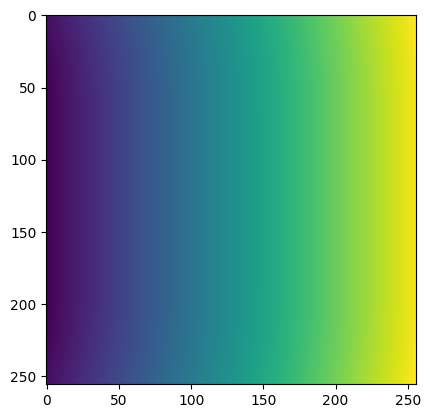

In [30]:
# Define rectangle
center        = torch.nn.Parameter(torch.tensor([-1.0, 0.5], dtype=dtype, device=device))
size          = torch.nn.Parameter(torch.tensor([0.5, 0.5], dtype=dtype, device=device))
angle         = torch.nn.Parameter(torch.tensor(0.0, dtype=dtype, device=device))
corner_radius = torch.tensor(0.0, dtype=dtype, device=device)

rect = Rectangle(center=center, size=size, angle=angle, corner_radius=corner_radius)
rect_sdf = rect.sdf(X, Y)

plt.imshow(rect_sdf.cpu().detach())

In [39]:
rect_cell = UnitCell(lattice=lattice, scene=rect)
rect_cell.to(device='cuda:0')


rect_cell.scene.center
# rect_cell_sdf = rect_cell.sdf(X, Y)

# plt.imshow(rect_cell_sdf.cpu().detach())

Parameter containing:
tensor([-1.0000,  0.5000], device='cuda:0', requires_grad=True)